In [1]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)
print("All good!")

2.4.4
3.0.2
All good!


In [2]:
import pathforge
print("working!")

working!


In [3]:
%load_ext autoreload
%autoreload 2

import pathforge as pf
print(pf.__version__)

0.1.0


In [4]:
import pathforge
print(pathforge.__file__)

C:\Users\franc\OneDrive\Documents\pathforge\pathforge\__init__.py


In [5]:
import pathforge as pf
import numpy as np
import pandas as pd

# Create some fake price data to test with
np.random.seed(42)
returns = np.random.normal(0.0005, 0.015, 500)
prices = 100 * np.cumprod(1 + returns)
dates = pd.date_range("2020-01-01", periods=500, freq="B")
price_series = pd.Series(prices, index=dates)

# Test the library
forge = pf.PathForge(price_series)
forge.fit(model="gbm")
sim = forge.simulate(days=252, n_paths=100, seed=42)

print(sim.paths.shape)
sim.summary()

(253, 100)
Paths         : 100
Days          : 252
Start price   : 128.0541

Final price distribution:
  Mean        : 144.6786
  Median      : 143.6003
  Std         : 33.7817
  5th pct     : 92.9857
  95th pct    : 207.1807

Return distribution:
  Mean        : 12.98%
  Median      : 12.14%
  5th pct     : -27.39%
  95th pct    : 61.79%


GARCH ok: (253, 100)
Bootstrap ok: (253, 100)
DataFrame shape: (253, 100)
       path_0      path_1      path_2      path_3      path_4      path_5  \
0  128.054149  128.054149  128.054149  128.054149  128.054149  128.054149   
1  129.039975  127.841822  129.326500  131.000337  127.661857  127.661888   
2  126.431508  127.101475  128.724846  129.513532  127.407083  128.469686   
3  127.145077  128.200581  130.838022  131.583102  124.900785  126.758932   
4  125.652698  127.197144  132.331533  132.817680  124.908867  127.024826   

       path_6      path_7      path_8      path_9  ...     path_90  \
0  128.054149  128.054149  128.054149  128.054149  ...  128.054149   
1  131.108508  129.554211  127.221277  129.126916  ...  128.284590   
2  134.842457  129.935206  127.751040  129.033731  ...  127.493216   
3  135.917121  130.968357  128.769211  136.598546  ...  127.151259   
4  138.543910  129.883346  129.856624  136.244035  ...  125.530720   

      path_91     path_92     path_93     

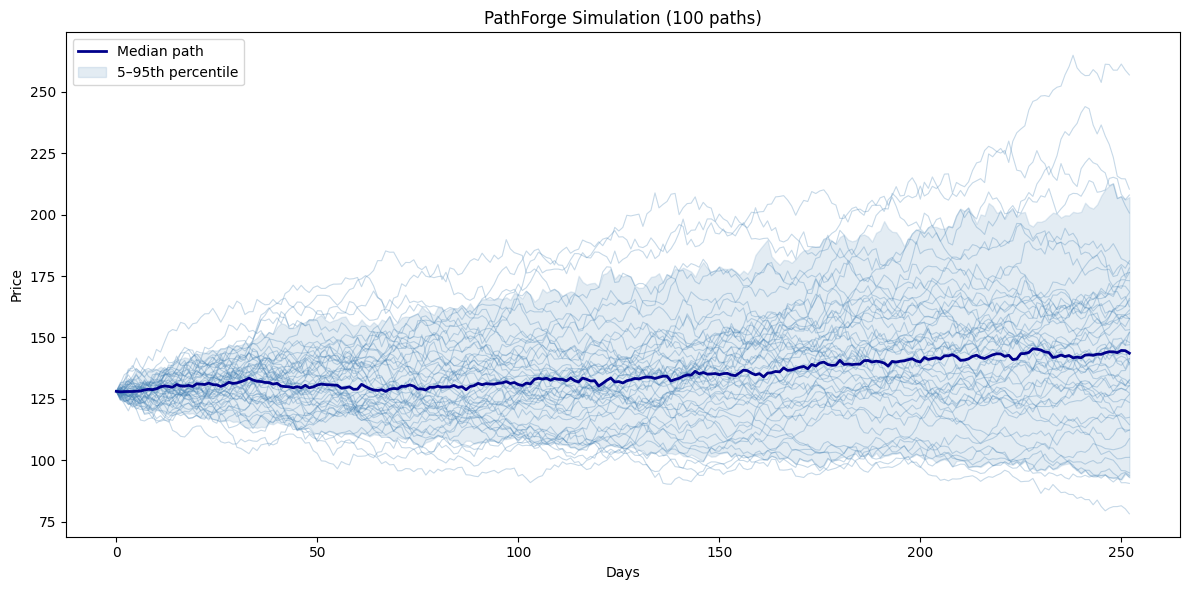

In [6]:
# Test GARCH
forge2 = pf.PathForge(price_series)
forge2.fit(model="garch")
sim2 = forge2.simulate(days=252, n_paths=100, seed=42)
print("GARCH ok:", sim2.paths.shape)

# Test Bootstrap
forge3 = pf.PathForge(price_series)
forge3.fit(model="bootstrap")
sim3 = forge3.simulate(days=252, n_paths=100, seed=42)
print("Bootstrap ok:", sim3.paths.shape)

# Test DataFrame output
df = sim.to_dataframe()
print("DataFrame shape:", df.shape)
print(df.head())

# Test plot
sim.plot()

In [7]:
import yfinance as yf

# Download 5 years of Apple data
ticker = yf.Ticker("AAPL")
hist = ticker.history(period="5y")

# We just want the closing price
prices = hist["Close"]
print(prices.head())
print(f"Downloaded {len(prices)} days of data")

Date
2021-04-05 00:00:00-04:00    122.626030
2021-04-06 00:00:00-04:00    122.927956
2021-04-07 00:00:00-04:00    124.574043
2021-04-08 00:00:00-04:00    126.970078
2021-04-09 00:00:00-04:00    129.541412
Name: Close, dtype: float64
Downloaded 1255 days of data


Paths         : 100
Days          : 252
Start price   : 255.6300

Final price distribution:
  Mean        : 338.2117
  Median      : 333.4919
  Std         : 81.4818
  5th pct     : 237.6957
  95th pct    : 491.7042

Return distribution:
  Mean        : 32.31%
  Median      : 30.46%
  5th pct     : -7.02%
  95th pct    : 92.35%


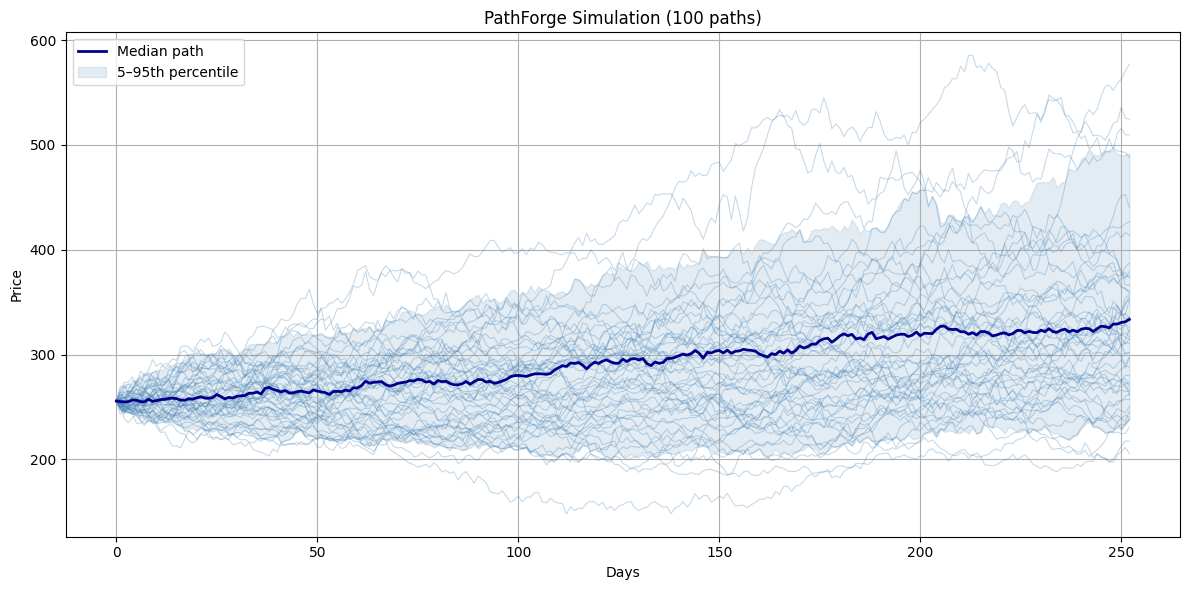

In [10]:
forge = pf.PathForge(prices)
forge.fit(model="garch")
sim = forge.simulate(days=252, n_paths=100, seed=42)

sim.summary()
sim.plot()

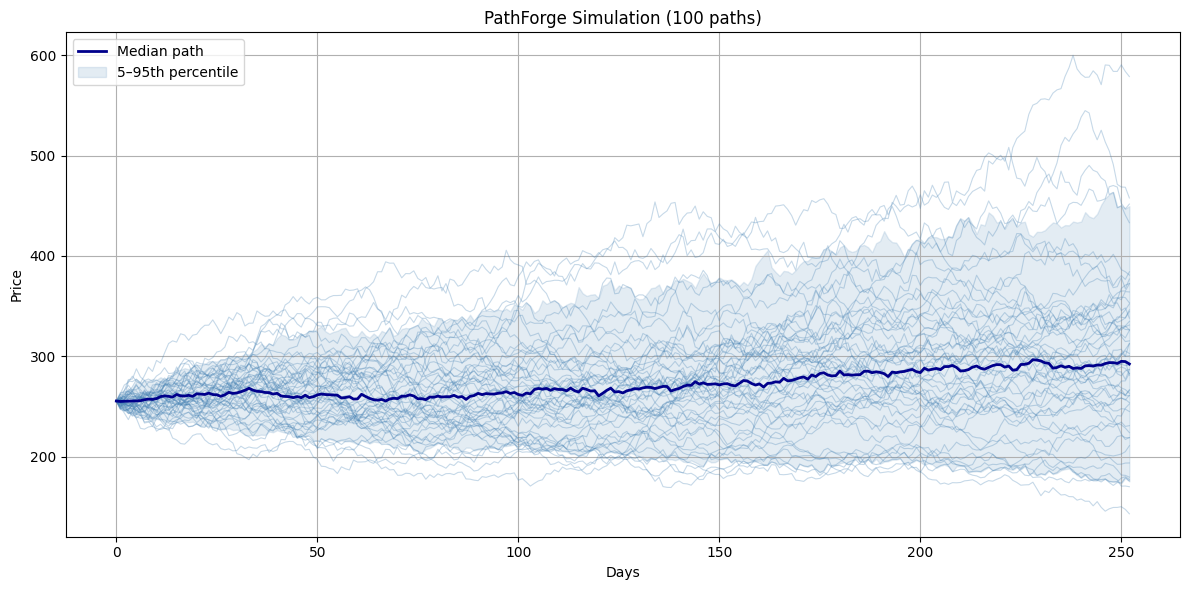

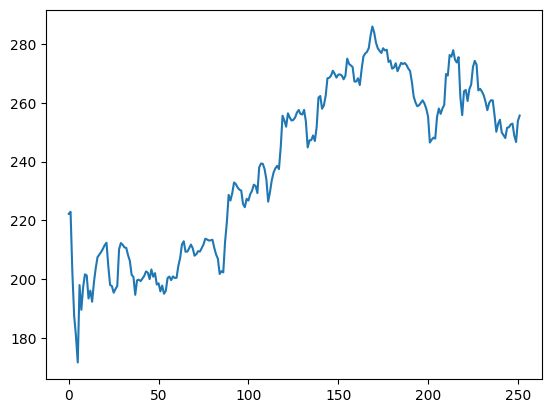

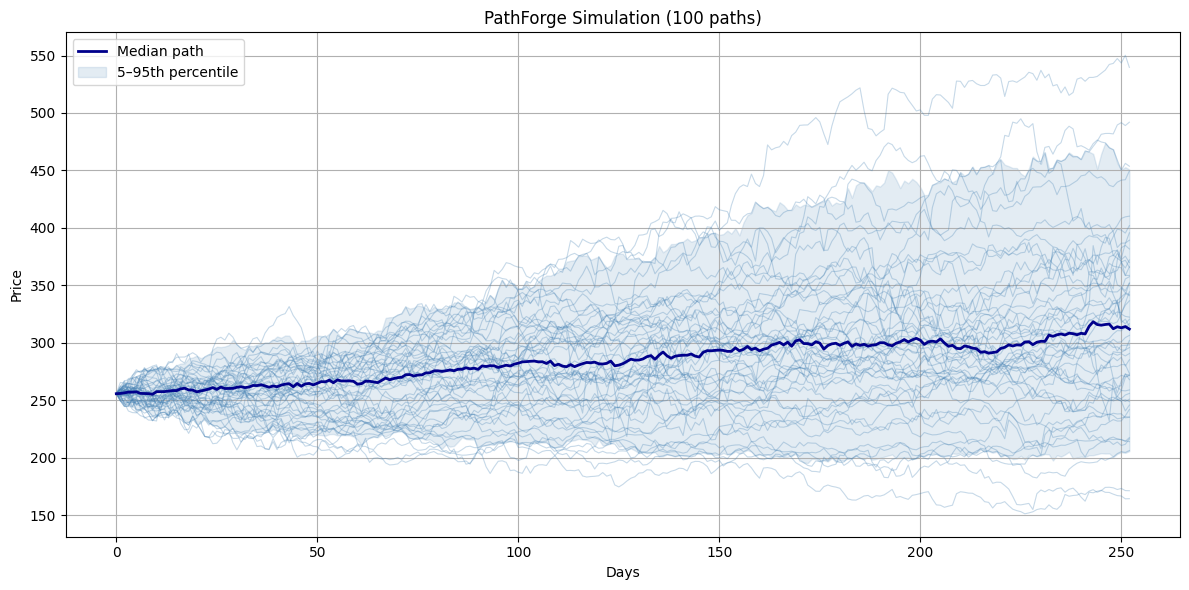

In [13]:
# GBM
import matplotlib.pyplot as plt
forge_gbm = pf.PathForge(prices)
forge_gbm.fit(model="gbm")
sim_gbm = forge_gbm.simulate(days=252, n_paths=100, seed=42)
sim_gbm.plot()
plt.plot(np.arange(252),prices[-252:])

# Bootstrap
forge_bs = pf.PathForge(prices)
forge_bs.fit(model="bootstrap")
sim_bs = forge_bs.simulate(days=252, n_paths=100, seed=42)
sim_bs.plot()
